In [5]:
# Core libraries
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

# Scikit-learn: metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Scikit-learn: utilities
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance


## 1. Import Libraries

Import the libraries needed for data loading and preprocessing.

In [6]:
%pip install pandas numpy scikit-learn

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Load the Training Dataset

Load the training dataset that contains the target variable.

In [8]:
from pathlib import Path

# PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# DATA_PATH = PROJECT_ROOT / "data" / "aug_train.csv"
df = pd.read_csv("/content/aug_train.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 3. Initial Data Inspection

Inspect the dataset structure, data types, statistical summary, and missing values before starting the preprocessing steps.

In [9]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [10]:
# Statistical summary of numerical features
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

gender                 4508
enrolled_university     386
education_level         460
major_discipline       2813
experience               65
company_size           5938
company_type           6140
last_new_job            423
dtype: int64


## 4. Separate Features and Target

Separate the input features from the target variable.

In [12]:
# Target column
target_column = "target"

# Separate features and target
X = df.drop(columns=[target_column]).copy()
y = df[target_column].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (19158, 13)
Target shape: (19158,)


## 5. Explore Ordinal Categorical Values

Inspect the unique values in `education_level` and `company_size` to identify their categories and determine the appropriate logical ordering before applying ordinal encoding.

In [13]:
education_levels = df['education_level'].unique()
company_sizes = df['company_size'].unique()

print(f'Education Levels : {education_levels}')
print(f'Company Sizes : {company_sizes}')

Education Levels : ['Graduate' 'Masters' 'High School' nan 'Phd' 'Primary School']
Company Sizes : [nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' '10/49' '100-500'
 '500-999']


## 6. Convert Experience to Numeric

Convert the `experience` feature from text categories into numeric years of experience.

In [14]:
# Convert experience values into numeric years
def convert_experience(value):
    if pd.isna(value):
        return np.nan
    elif value == ">20":
        return 21
    elif value == "<1":
        return 0
    else:
        return float(value)

X["experience"] = X["experience"].apply(convert_experience)

display(X[["experience"]].head(10))

,experience
0,21.0
1,15.0
2,5.0
3,0.0
4,21.0
5,11.0
6,5.0
7,13.0
8,7.0
9,17.0


## 7. Train/Test Split

Split the data into 80% training and 20% testing while preserving the target class distribution.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (15326, 13)
X_test: (3832, 13)
y_train: (15326,)
y_test: (3832,)


## 8. Define Categorical and Numerical Features

Identify the categorical and numerical features before handling missing values.

In [16]:
# Numerical features
numerical_features = [
    "city_development_index",
    "training_hours",
    "experience"
]

# Ordinal categorical features
ordinal_features = [
    "education_level",
    "company_size",
    "last_new_job"
]

# Nominal categorical features
nominal_features = [
    "gender",
    "relevent_experience",
    "enrolled_university",
    "major_discipline",
    "company_type"
]

# City will be handled separately using frequency encoding
city_feature = ["city"]

print("Numerical features:")
print(numerical_features)

print("\nOrdinal features:")
print(ordinal_features)

print("\nNominal features:")
print(nominal_features)

print("\nCity feature:")
print(city_feature)

Numerical features:
['city_development_index', 'training_hours', 'experience']

Ordinal features:
['education_level', 'company_size', 'last_new_job']

Nominal features:
['gender', 'relevent_experience', 'enrolled_university', 'major_discipline', 'company_type']

City feature:
['city']


## 9. Handle Missing Numerical Values

Fill missing numerical values using the median calculated from the training data.

In [17]:
# Create numerical imputer
numerical_imputer = SimpleImputer(strategy="median")

# Fit on training data and transform training data
X_train[numerical_features] = numerical_imputer.fit_transform(
    X_train[numerical_features]
)

# Apply the same transformation to test data
X_test[numerical_features] = numerical_imputer.transform(
    X_test[numerical_features]
)

## 10. Handle Missing Categorical Values

Replace missing categorical values with `Unknown`.

In [18]:
# All categorical columns that need categorical imputation
categorical_features = ordinal_features + nominal_features + city_feature

# Create categorical imputer
categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Unknown"
)

# Fit on training data
X_train[categorical_features] = categorical_imputer.fit_transform(
    X_train[categorical_features]
)

# Apply the same transformation to test data
X_test[categorical_features] = categorical_imputer.transform(
    X_test[categorical_features]
)

print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [19]:
X_train.columns.tolist()

['enrollee_id',
 'city',
 'city_development_index',
 'gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job',
 'training_hours']

In [20]:
eda_df = X_train.copy()
eda_df['target'] = y_train.values

print("Shape:", eda_df.shape)
eda_df.head()

Shape: (15326, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
17855,6135,city_21,0.624,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,10.0,50-99,Pvt Ltd,1,90.0,0.0
17664,6455,city_103,0.920,Male,No relevent experience,no_enrollment,Primary School,Unknown,5.0,Unknown,Unknown,never,15.0,0.0
13404,5856,city_50,0.896,Male,Has relevent experience,no_enrollment,Graduate,STEM,12.0,1000-4999,NGO,>4,36.0,0.0
13366,27191,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,5.0,100-500,Funded Startup,1,53.0,0.0
15670,16751,city_67,0.855,Female,Has relevent experience,Full time course,Graduate,STEM,5.0,Unknown,Unknown,1,158.0,1.0


target
0.0    11504
1.0     3822
Name: count, dtype: int64

target
0.0    75.061986
1.0    24.938014
Name: proportion, dtype: float64


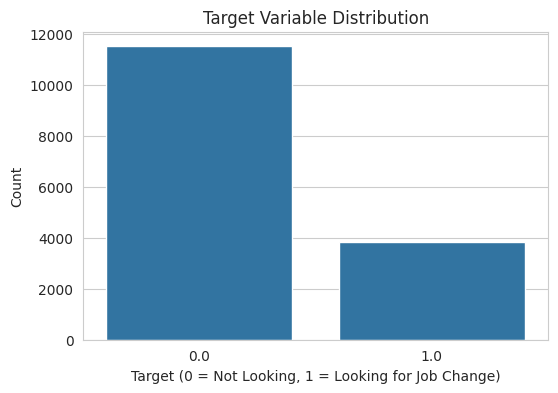

In [21]:
print(eda_df['target'].value_counts())
print()
print(eda_df['target'].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=eda_df)
plt.title('Target Variable Distribution')
plt.xlabel('Target (0 = Not Looking, 1 = Looking for Job Change)')
plt.ylabel('Count')
plt.show()

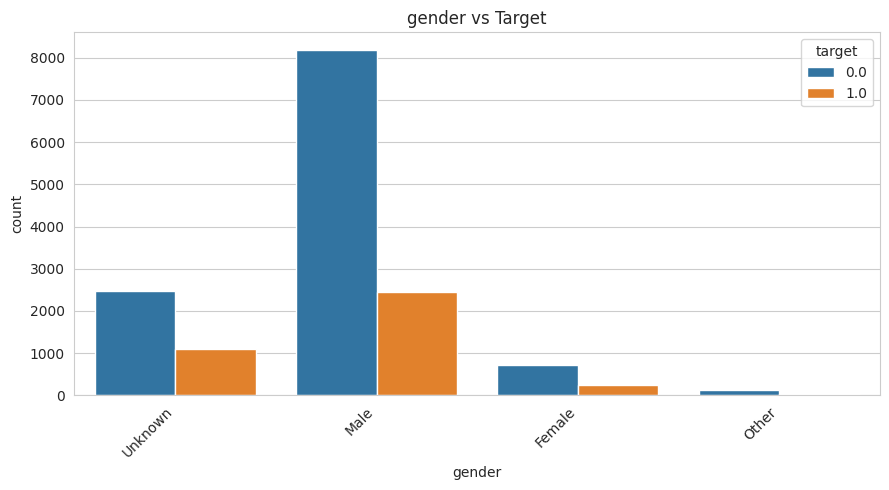

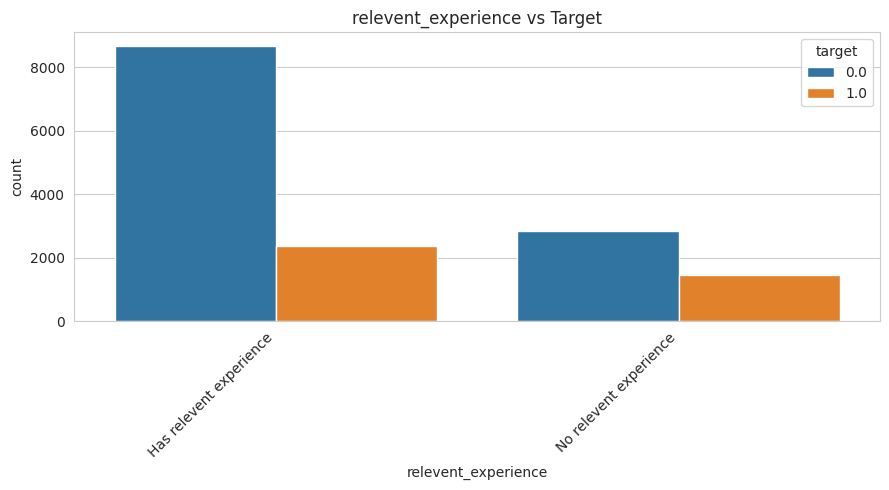

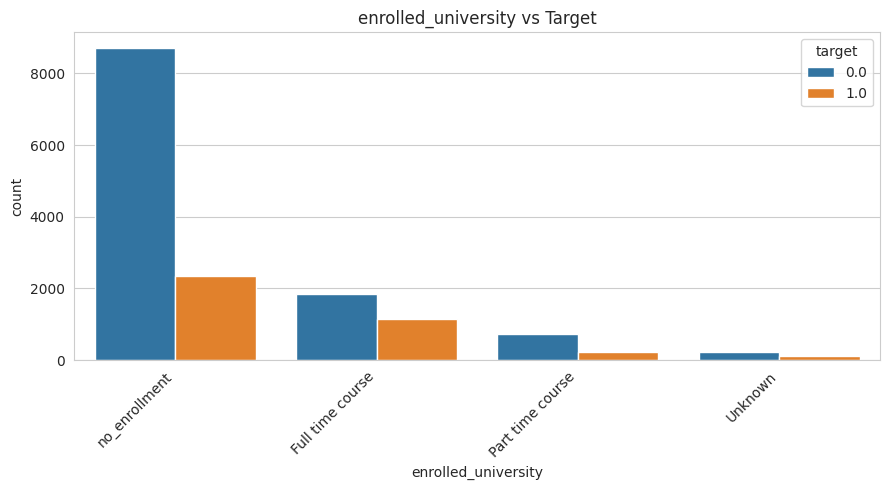

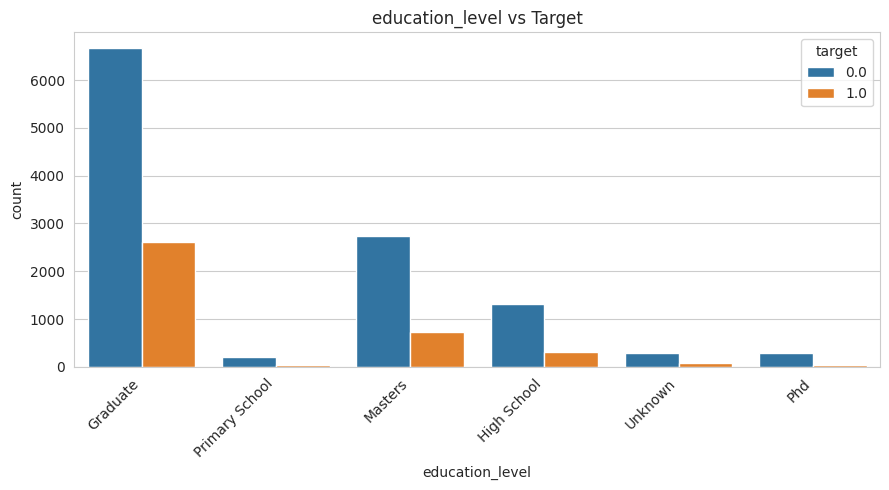

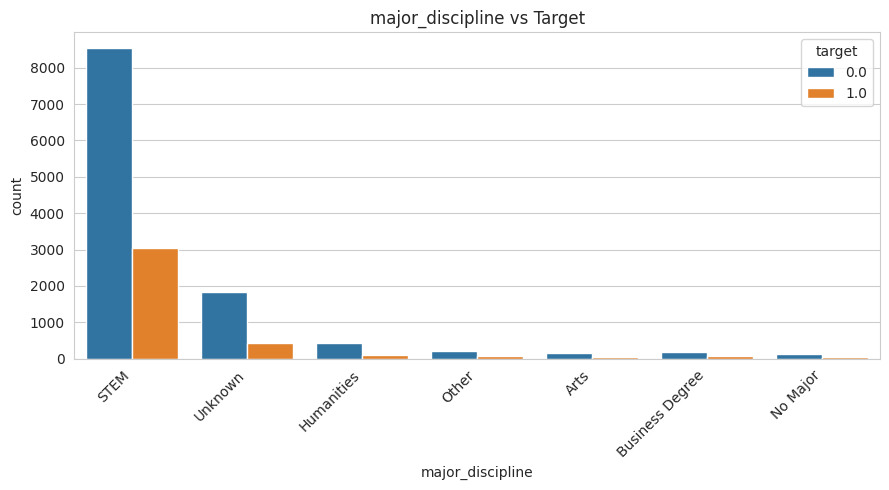

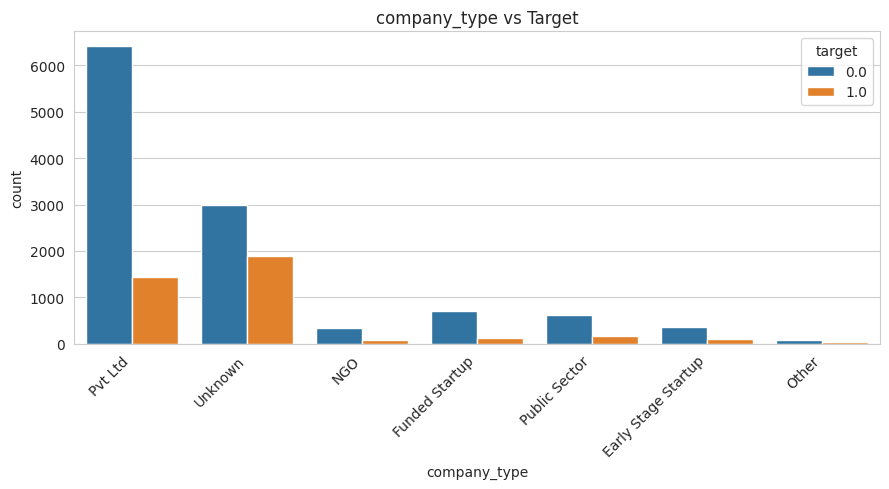

In [22]:
categorical_cols = ['gender', 'relevent_experience', 'enrolled_university',
                     'education_level', 'major_discipline', 'company_type']

for col in categorical_cols:
    plt.figure(figsize=(9, 5))
    sns.countplot(x=col, hue='target', data=eda_df)
    plt.title(f'{col} vs Target')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

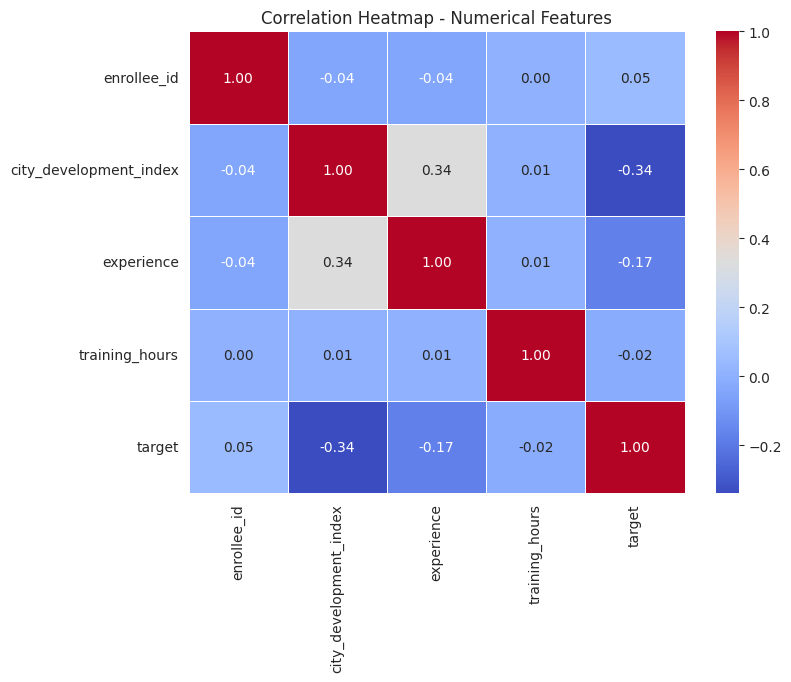

In [23]:
numerical_cols = eda_df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = eda_df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.show()

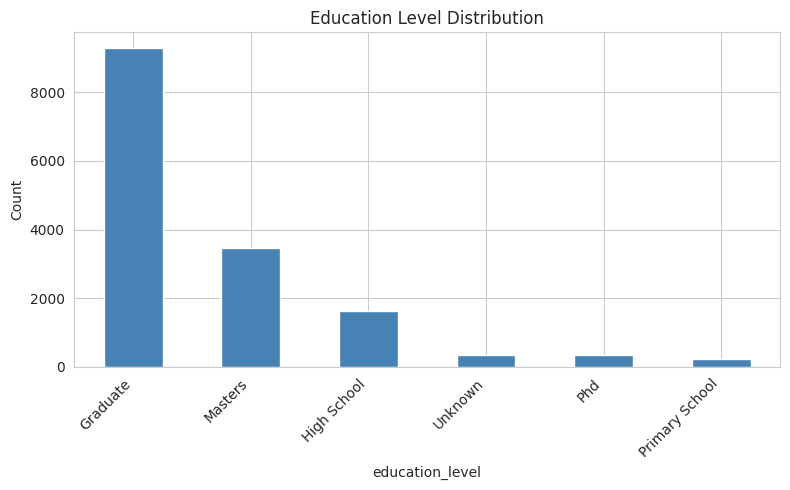

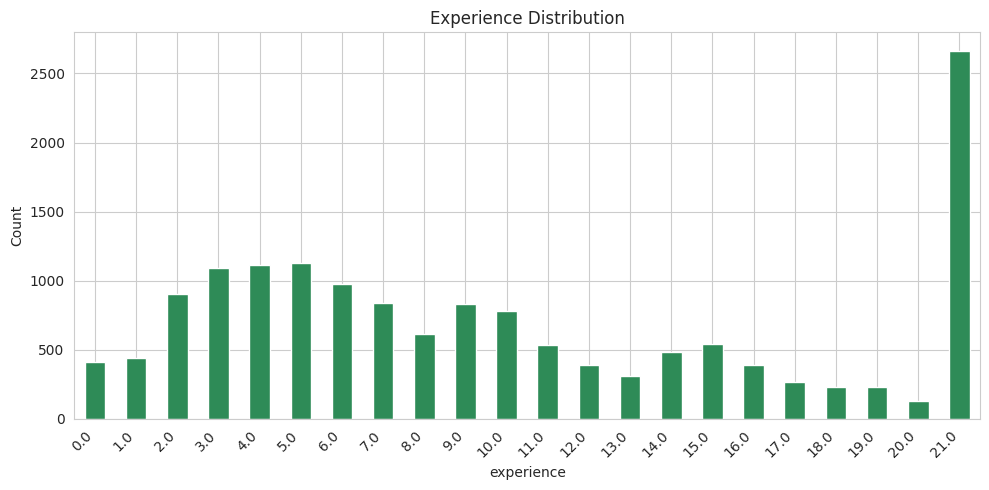

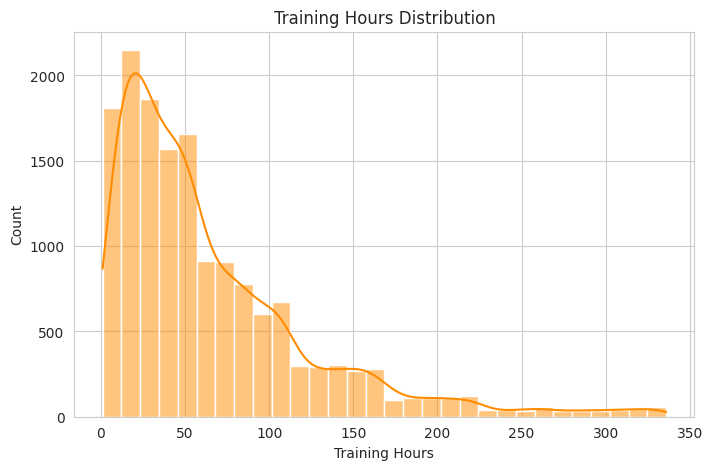

In [24]:
plt.figure(figsize=(8, 5))
eda_df['education_level'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Education Level Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
eda_df['experience'].value_counts().sort_index().plot(kind='bar', color='seagreen')
plt.title('Experience Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(eda_df['training_hours'], bins=30, kde=True, color='darkorange')
plt.title('Training Hours Distribution')
plt.xlabel('Training Hours')
plt.show()



- الـ Target متوازن؟ لا، الداتا Imbalanced: 75% من المتقدمين مش بيدوروا على تغيير وظيفة، و25% بس بيدوروا (Target=1).
- أكثر Features تأثيرًا: عدم وجود "relevant experience" ونوع الشركة "Pvt Ltd" مرتبطين بزيادة احتمالية البحث عن وظيفة جديدة.
- في الـ Correlation Heatmap، فيه ارتباط عكسي متوسط (-0.34) بين city_development_index والـ target، يعني كل ما مؤشر تطور المدينة أعلى كل ما نسبة البحث عن وظيفة تقل.
- أكثر صفة شيوعًا بين المتقدمين: تعليم Graduate، تخصص STEM، ويشتغلوا في شركات Pvt Ltd، وأغلبهم عندهم ساعات تدريب قليلة نسبيًا.

## 11. Ordinal Encoding

Convert ordinal categorical features into numerical values while preserving their logical order.

In [25]:
# Define logical order for education level
education_mapping = {
    "Unknown": -1,
    "Primary School": 0,
    "High School": 1,
    "Graduate": 2,
    "Masters": 3,
    "Phd": 4
}

# Define logical order for company size
company_size_mapping = {
    "Unknown": -1,
    "<10": 0,
    "10/49": 1,
    "50-99": 2,
    "100-500": 3,
    "500-999": 4,
    "1000-4999": 5,
    "5000-9999": 6,
    "10000+": 7
}

# Define logical order for last new job
last_new_job_mapping = {
    "Unknown": -1,
    "never": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    ">4": 5
}

# Apply mappings
X_train["education_level"] = X_train["education_level"].map(
    education_mapping
)

X_test["education_level"] = X_test["education_level"].map(
    education_mapping
)

X_train["company_size"] = X_train["company_size"].map(
    company_size_mapping
)

X_test["company_size"] = X_test["company_size"].map(
    company_size_mapping
)

X_train["last_new_job"] = X_train["last_new_job"].map(
    last_new_job_mapping
)

X_test["last_new_job"] = X_test["last_new_job"].map(
    last_new_job_mapping
)

# Quick check: confirm no NaN reappeared after mapping
print("NaN after ordinal mapping - X_train:", X_train[["education_level", "company_size", "last_new_job"]].isna().sum().sum())
print("NaN after ordinal mapping - X_test:", X_test[["education_level", "company_size", "last_new_job"]].isna().sum().sum())


NaN after ordinal mapping - X_train: 0
NaN after ordinal mapping - X_test: 0


## 12. Frequency Encoding for City

Convert the high-cardinality `city` feature into one numerical feature based on the frequency of each city in the training data.

In [26]:
# Calculate city frequency
city_frequency = X_train["city"].value_counts(normalize=True)

# Map frequencies to training and testing data
X_train["city_freq"] = X_train["city"].map(city_frequency)
X_test["city_freq"] = X_test["city"].map(city_frequency)

# Unseen cities in test data get frequency 0
X_test["city_freq"] = X_test["city_freq"].fillna(0)

# Remove the original city column
X_train = X_train.drop(columns=["city"])
X_test = X_test.drop(columns=["city"])

print("City frequency encoding completed.")

City frequency encoding completed.


## 13. Prepare Numerical Features for Scaling

Collect all numerical and ordinal features that should be scaled.

In [27]:
# Numerical features selected for scaling
scaling_features = [
    "city_development_index",
    "training_hours",
    "experience",
    "city_freq"
]

print("Features to scale:")
print(scaling_features)

Features to scale:
['city_development_index', 'training_hours', 'experience', 'city_freq']


## 14. One-Hot Encode Nominal Features

Convert nominal categorical features into numerical binary features.

In [28]:
# Create One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit encoder on training data only
X_train_encoded = encoder.fit_transform(
    X_train[nominal_features]
)

# Transform test data using the same encoder
X_test_encoded = encoder.transform(
    X_test[nominal_features]
)

# Get feature names
encoded_feature_names = encoder.get_feature_names_out(
    nominal_features
)

# Convert encoded arrays to DataFrames
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (15326, 24)
Encoded test shape: (3832, 24)


## 15. Combine Processed Features

Combine numerical, ordinal, frequency-encoded, and One-Hot encoded features into the final feature matrices.

In [29]:
# Features that remain as numerical/ordinal columns
base_features = [
    "city_development_index",
    "training_hours",
    "experience",
    "education_level",
    "company_size",
    "last_new_job",
    "city_freq"
]

# Select base features
X_train_base = X_train[base_features].copy()
X_test_base = X_test[base_features].copy()

# Combine with One-Hot encoded features
X_train_processed = pd.concat(
    [X_train_base, X_train_encoded],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_base, X_test_encoded],
    axis=1
)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (15326, 31)
Processed X_test shape: (3832, 31)


## 16. Feature Scaling

Apply StandardScaler to the selected numerical features using statistics learned from the training data only.

In [30]:
# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_processed[scaling_features] = scaler.fit_transform(
    X_train_processed[scaling_features]
)

# Apply the same scaler to test data
X_test_processed[scaling_features] = scaler.transform(
    X_test_processed[scaling_features]
)

print("Feature scaling completed.")

Feature scaling completed.


## 17. Create Final Train/Test Variables

Create the final variables that will be passed to the next stage of the project.

In [31]:
# Final processed feature matrices
X_train = X_train_processed.copy()
X_test = X_test_processed.copy()

# Reset indexes
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Final variables created successfully.")

Final variables created successfully.


## 18. Validate the Final Outputs

Check that the final datasets contain no missing values and that the train/test target distributions remain balanced.

In [32]:
# Check missing values
train_missing = X_train.isna().sum().sum()
test_missing = X_test.isna().sum().sum()

print("Missing values in X_train:", train_missing)
print("Missing values in X_test:", test_missing)

# Check shapes
print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Check feature consistency
print(
    "\nSame feature columns:",
    list(X_train.columns) == list(X_test.columns)
)

# Check target distribution
print("\nTarget distribution - Train:")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution - Test:")
print(y_test.value_counts(normalize=True))

# Final validation
assert train_missing == 0
assert test_missing == 0
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert list(X_train.columns) == list(X_test.columns)

print("\nData Cleaning & Preprocessing completed successfully!")
print("Data is ready for modeling.")

Missing values in X_train: 0
Missing values in X_test: 0

Final shapes:
X_train: (15326, 31)
X_test: (3832, 31)
y_train: (15326,)
y_test: (3832,)

Same feature columns: True

Target distribution - Train:
target
0.0    0.75062
1.0    0.24938
Name: proportion, dtype: float64

Target distribution - Test:
target
0.0    0.750783
1.0    0.249217
Name: proportion, dtype: float64

Data Cleaning & Preprocessing completed successfully!
Data is ready for modeling.


## 19.Creat Logistic Regression Model
Create the Logistic Regression model object that will be used for training and prediction.

In [33]:
from sklearn.linear_model import LogisticRegression

##20.Create The Model Object

In [34]:
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

##21. Train The Model
Train the Logistic Regression model using the training data

In [35]:
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

##22. Make Predictions
Make predictions on the test data using the trained model.

In [36]:
y_pred=model.predict(X_test)

##23.Evaluate Model Performance
import evalution metrics,Calculate the evaluation metrics for the Logistic Regression model.

In [37]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)



Accuracy : 0.7507828810020877
Precision: 0.5
Recall   : 0.7811518324607329
F1 Score : 0.6097261953412342


##24. Confusion Matrix
Generate the confusion matrix to analyze the classification results.

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2131  746]
 [ 209  746]]


##25.Confusion Matrix
Visualize the confusion matrix

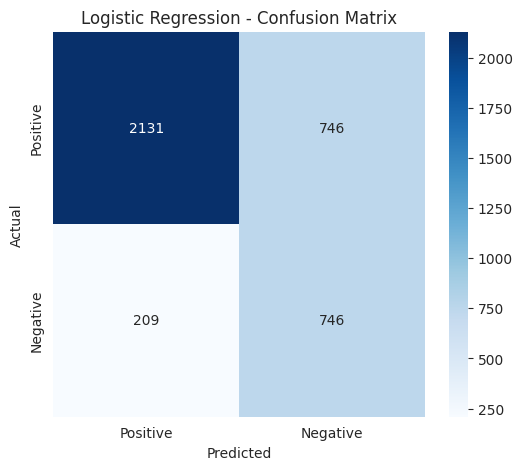

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

##26. Save the Model
Save the trained Logistic Regression model for later use.

In [40]:
import joblib
import os

# Create the folder automatically if it doesn't exist
os.makedirs("models", exist_ok=True)

# save the model
joblib.dump(model, "models/logistic_regression.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


##27. Create Random Forest Model

In [41]:
from sklearn.ensemble import RandomForestClassifier
# Create the Random Forest model
rf_model=RandomForestClassifier(n_estimators=200,
                                random_state=42,
                                class_weight="balanced",n_jobs=-1)

##28. Train Random Forest

In [42]:
# Train the Random Forest using the same training data
rf_model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

##29. Make Random Forest Predictions

In [43]:
# Make predictions on the test set
rf_pred=rf_model.predict(X_test)

##30. Evaluate Random Forest Performance

In [44]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Performance
-------------------------
Accuracy : 0.7815762004175365
Precision: 0.5762273901808785
Recall   : 0.46701570680628274
F1 Score : 0.5159051474840949


## 31. Random Forest Classification Report

In [45]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      2877
         1.0       0.58      0.47      0.52       955

    accuracy                           0.78      3832
   macro avg       0.70      0.68      0.69      3832
weighted avg       0.77      0.78      0.77      3832



##32. Random Forest Confusion Matrix

In [46]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)



Random Forest Confusion Matrix:
[[2549  328]
 [ 509  446]]


## 33. Visualize Random Forest Confusion Matrix

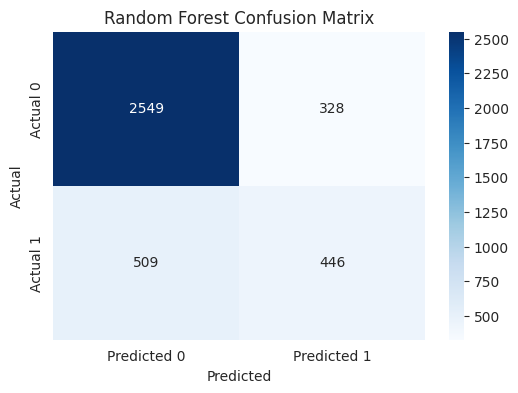

In [47]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

##34. Random Forest Feature Importance

In [48]:
# Extract feature importance from the trained Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})
# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
1,training_hours,0.189787
0,city_development_index,0.180521
2,experience,0.121616
6,city_freq,0.105621
4,company_size,0.098752
5,last_new_job,0.066441
3,education_level,0.040838
30,company_type_Unknown,0.029313
29,company_type_Pvt Ltd,0.017966
8,gender_Male,0.013278


##35. Top 10 Important Features

In [49]:
# Display the 10 most important features
feature_importance.head(10)

,Feature,Importance
1,training_hours,0.189787
0,city_development_index,0.180521
2,experience,0.121616
6,city_freq,0.105621
4,company_size,0.098752
5,last_new_job,0.066441
3,education_level,0.040838
30,company_type_Unknown,0.029313
29,company_type_Pvt Ltd,0.017966
8,gender_Male,0.013278


## 37. Create ExtraTrees Model


In [50]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = ExtraTreesClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


## 38. Train ExtraTrees


In [51]:
extra_trees.fit(X_train, y_train)
extra_pred = extra_trees.predict(X_test)


## 39. Evaluate ExtraTrees Performance


In [52]:
extra_accuracy = accuracy_score(y_test, extra_pred)
extra_precision = precision_score(y_test, extra_pred, zero_division=0)
extra_recall = recall_score(y_test, extra_pred, zero_division=0)
extra_f1 = f1_score(y_test, extra_pred, zero_division=0)

extra_balanced_accuracy = balanced_accuracy_score(y_test, extra_pred)
extra_roc_auc = roc_auc_score(
    y_test,
    extra_trees.predict_proba(X_test)[:, 1]
)

print("ExtraTrees Performance")
print("----------------------")
print("Accuracy :", extra_accuracy)
print("Precision:", extra_precision)
print("Recall   :", extra_recall)
print("F1 Score :", extra_f1)
print("Balanced Accuracy:", extra_balanced_accuracy)
print("ROC-AUC :", extra_roc_auc)


ExtraTrees Performance
----------------------
Accuracy : 0.785490605427975
Precision: 0.5518316445830086
Recall   : 0.7413612565445026
F1 Score : 0.6327077747989276
Balanced Accuracy: 0.7707501451300893
ROC-AUC : 0.8023044292429395


## 40. Create HistGradientBoosting Model


In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

hist_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)


## 41. Train HistGradientBoosting


In [54]:
hist_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

hist_model.fit(
    X_train,
    y_train,
    sample_weight=hist_sample_weights
)

hist_pred = hist_model.predict(X_test)


## 42. Evaluate HistGradientBoosting Performance


In [55]:
hist_accuracy = accuracy_score(y_test, hist_pred)
hist_precision = precision_score(y_test, hist_pred, zero_division=0)
hist_recall = recall_score(y_test, hist_pred, zero_division=0)
hist_f1 = f1_score(y_test, hist_pred, zero_division=0)

hist_balanced_accuracy = balanced_accuracy_score(y_test, hist_pred)
hist_roc_auc = roc_auc_score(
    y_test,
    hist_model.predict_proba(X_test)[:, 1]
)

print("HistGradientBoosting Performance")
print("--------------------------------")
print("Accuracy :", hist_accuracy)
print("Precision:", hist_precision)
print("Recall   :", hist_recall)
print("F1 Score :", hist_f1)
print("Balanced Accuracy:", hist_balanced_accuracy)
print("ROC-AUC :", hist_roc_auc)


HistGradientBoosting Performance
--------------------------------
Accuracy : 0.7943632567849687
Precision: 0.5643793369313801
Recall   : 0.7664921465968586
F1 Score : 0.650088809946714
Balanced Accuracy: 0.7850535116022179
ROC-AUC : 0.8204559723534004


##36. Save Random Forest Model

In [56]:
import os
import joblib

os.makedirs("models", exist_ok=True)

# Save the trained Random Forest model
joblib.dump(
    rf_model,
    "models/random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


## 44. Model Comparison


In [57]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "ExtraTrees",
        "HistGradientBoosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        extra_accuracy,
        hist_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        extra_precision,
        hist_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        extra_recall,
        hist_recall
    ],
    "F1": [
        f1,
        rf_f1,
        extra_f1,
        hist_f1
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, rf_pred),
        extra_balanced_accuracy,
        hist_balanced_accuracy
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        extra_roc_auc,
        hist_roc_auc
    ]
}

comparison_df = pd.DataFrame(comparison)

selection_metrics = [
    "Recall",
    "F1",
    "Balanced Accuracy",
    "ROC-AUC"
]

comparison_df["Selection Score"] = comparison_df[selection_metrics].mean(axis=1)

comparison_df


,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC-AUC,Selection Score
0,Logistic Regression,0.750783,0.500000,0.781152,0.609726,0.760927,0.802790,0.738649
1,Random Forest,0.781576,0.576227,0.467016,0.515905,0.676504,0.800336,0.614940
2,ExtraTrees,0.785491,0.551832,0.741361,0.632708,0.770750,0.802304,0.736781
3,HistGradientBoosting,0.794363,0.564379,0.766492,0.650089,0.785054,0.820456,0.755523


## 45. Visual Model Comparison


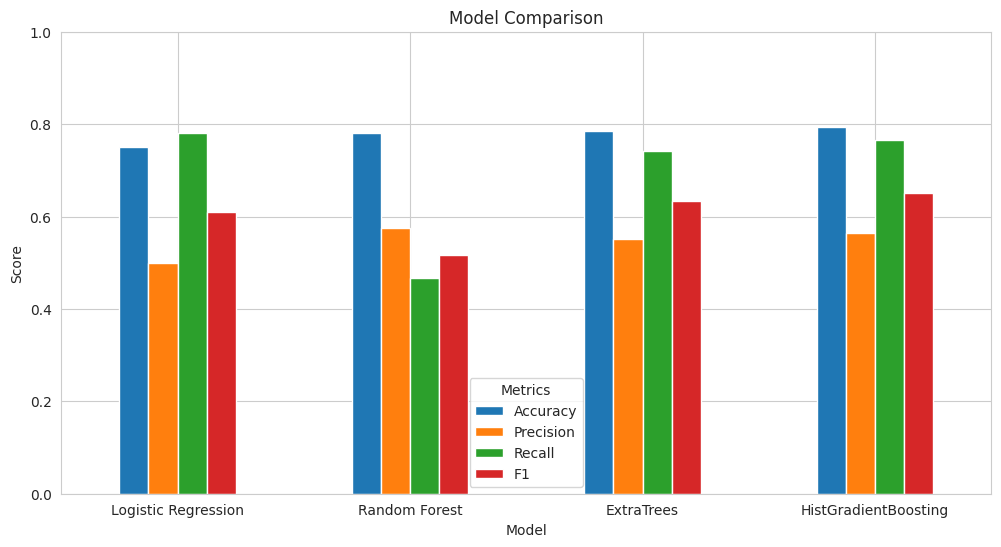

In [58]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()


## 46. Best Model Selection


In [59]:
selected_row = comparison_df.sort_values(
    "Selection Score",
    ascending=False
).iloc[0]

selected_name = selected_row["Model"]

model_objects = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "ExtraTrees": extra_trees,
    "HistGradientBoosting": hist_model
}

selected_model = model_objects[selected_name]

print("Selected Model:", selected_name)
print("Selection Score:", selected_row["Selection Score"])
print()
print("Selection Rule:")
print("Highest mean of Recall, F1, Balanced Accuracy, and ROC-AUC.")


Selected Model: HistGradientBoosting
Selection Score: 0.7555226101247977

Selection Rule:
Highest mean of Recall, F1, Balanced Accuracy, and ROC-AUC.


## 47. Save All Models


In [60]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/logistic_regression.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(extra_trees, "models/extra_trees.pkl")
joblib.dump(hist_model, "models/hist_gradient_boosting.pkl")

print("All four models saved successfully.")


All four models saved successfully.


## 48. Feature Importance of Selected Model


In [61]:
if hasattr(selected_model, "feature_importances_"):
    selected_importance = selected_model.feature_importances_
    importance_method = "native feature importance"
else:
    from sklearn.inspection import permutation_importance

    permutation = permutation_importance(
        selected_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        scoring="roc_auc",
        n_jobs=-1
    )

    selected_importance = permutation.importances_mean
    importance_method = "permutation importance (ROC-AUC)"

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": selected_importance
})

feature_importance["Method"] = importance_method

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)


,Feature,Importance,Method
0,city_development_index,0.184885,permutation importance (ROC-AUC)
4,company_size,0.070822,permutation importance (ROC-AUC)
29,company_type_Pvt Ltd,0.013776,permutation importance (ROC-AUC)
3,education_level,0.012294,permutation importance (ROC-AUC)
2,experience,0.007827,permutation importance (ROC-AUC)
11,relevent_experience_Has relevent experience,0.004592,permutation importance (ROC-AUC)
5,last_new_job,0.004284,permutation importance (ROC-AUC)
6,city_freq,0.003756,permutation importance (ROC-AUC)
1,training_hours,0.003384,permutation importance (ROC-AUC)
30,company_type_Unknown,0.001419,permutation importance (ROC-AUC)


## 49. Top 10 Candidates by Confidence


In [62]:
selected_probability = selected_model.predict_proba(X_test)[:, 1]

top_candidates = X_test.copy()
top_candidates["confidence"] = selected_probability

top_candidates = top_candidates.sort_values(
    by="confidence",
    ascending=False
)

top_candidates.head(10)


,city_development_index,training_hours,experience,education_level,company_size,last_new_job,city_freq,gender_Female,gender_Male,gender_Other,...,major_discipline_STEM,major_discipline_Unknown,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown,confidence
1154,0.734358,-0.288757,-1.345234,2,-1,1,1.591095,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.858789
1858,0.734358,-0.222052,-0.902874,2,-1,1,1.591095,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.852186
15,0.734358,-0.688989,-0.755421,2,-1,1,1.591095,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.847674
541,0.734358,0.895261,-0.755421,2,-1,1,1.591095,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.847674
1585,0.734358,-0.372139,-1.197780,2,-1,1,1.591095,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.846976
3240,0.734358,-0.255405,-1.197780,2,-1,1,1.591095,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.846568
3791,0.734358,-0.222052,-1.345234,2,-1,1,1.591095,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.845346
3403,0.734358,1.412227,0.129298,2,-1,1,1.591095,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.840883
2323,0.734358,-0.288757,-1.197780,2,-1,1,1.591095,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.840698
3821,0.734358,-0.388815,-1.345234,2,-1,1,1.591095,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.837290
